# Layer 1 — Short-Volatility Backtest: Results & Strategy Walkthrough

This notebook re-runs the Layer 1 backtest in-memory, then walks through each strategy
(**A → D**) so you can see *why* each piece (delta hedging, EWMA timing, stop loss) is
in the design and how it changes the P&L.

The four strategies all sell an **at-the-money straddle on USO** (one call + one put,
same strike, ~30-day expiry) and roll roughly monthly. They differ only in:

| Strategy | Delta hedged daily? | EWMA entry filter? | Stop loss? |
|---|:---:|:---:|:---:|
| **A** — raw baseline | ❌ | ❌ | ❌ |
| **B** — hedged baseline | ✅ | ❌ | ❌ |
| **C** — timed, unhedged | ❌ | ✅ | ❌ |
| **D** — full Layer 1 baseline | ✅ | ✅ | ✅ |

Backtest window: **2020-05-04 → 2026-04-10** (post USO 1:8 reverse split, where chain
strikes and Bloomberg PX_LAST align).


## 1. Setup and data loading

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_loader import load_price_data, load_option_chain
from volatility_models import compute_ewma_vol
from option_selector import select_atm_straddle
from backtest_engine import STRATEGIES, run_backtest, build_chain_by_date
from metrics import calculate_performance_metrics

pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (11, 4)


In [2]:
price = load_price_data()
print(f"Price rows: {len(price):,}  ({price['date'].min().date()} → {price['date'].max().date()})")
price.head()


Price rows: 1,492  (2020-05-04 → 2026-04-10)


,date,cl1,cl2,co1,ovx,uso_close,uso_bid,uso_ask,uso_volume,log_return
0,2020-05-04,20.39,22.78,27.20,97.42,19.67,19.65,19.66,"14,044,779.00",NaN
1,2020-05-05,24.56,26.49,30.97,97.27,21.51,21.63,21.64,"20,954,778.00",0.09
2,2020-05-06,23.99,25.62,29.72,115.39,20.85,20.85,20.86,"17,295,781.00",-0.03
3,2020-05-07,23.55,24.83,29.46,110.62,20.47,20.46,20.47,"12,745,439.00",-0.02
4,2020-05-08,24.74,26.17,30.97,98.70,21.47,21.49,21.50,"10,523,513.00",0.05


**Note on USO prices.** USO underwent a 1-for-8 reverse split on 2020-04-29.
Bloomberg `PX_LAST` is split-adjusted (so 2010 prices look ~$300+) but option-chain
strikes are *not* — they are the actual tradable strikes at the time. To keep prices
and strikes consistent we restrict the backtest to dates after the reverse split.

In [3]:
chain = load_option_chain()
print(f"Option rows: {len(chain):,}")
chain.head()


Option rows: 2,015,055


,trade_date,strike,expiry,cp,last,bid,ask,iv_bid,iv_ask,oi,volume,delta,gamma,vega,theta,rho,mid,iv_mid,dte
0,2020-05-04,0.50,2020-05-08,c,19.02,1.91,1.97,0.00,0.00,16,100,1.00,0.00,0.00,0.00,0.00,1.94,0.00,4
1,2020-05-04,1.00,2020-05-08,c,18.52,1.41,1.47,0.00,0.00,78,1,1.00,0.00,0.00,0.00,0.00,1.44,0.00,4
2,2020-05-04,1.50,2020-05-08,c,18.02,0.92,0.93,0.00,0.00,93,3,1.00,0.00,0.00,0.00,0.00,0.93,0.00,4
3,2020-05-04,2.00,2020-05-08,c,17.52,0.44,0.48,0.00,0.00,1266,104,1.00,0.00,0.00,0.00,0.00,0.46,0.00,4
4,2020-05-04,2.50,2020-05-08,c,17.02,0.06,0.07,0.00,0.00,1034,889,1.00,0.00,0.00,0.00,0.00,0.07,0.00,4


In [4]:
chain_by_date = build_chain_by_date(chain)
ewma = compute_ewma_vol(price['log_return'], lam=0.94)
price['ewma_vol_daily']  = ewma['ewma_vol_daily'].values
price['ewma_vol_annual'] = ewma['ewma_vol_annual'].values


## 2. Underlying price and EWMA realized volatility

**Why EWMA?** A short-vol trade collects an *insurance premium* that is fair
only if implied vol > realized vol. We use an exponentially-weighted moving average of
squared log returns as a fast estimate of recent realized vol:

$$\sigma_t^2 = \lambda\,\sigma_{t-1}^2 + (1-\lambda)\,r_t^2,\qquad \lambda = 0.94$$

This is the same recursion RiskMetrics uses for daily risk. λ=0.94 gives ~25-day
half-life — recent shocks (Russia-Ukraine, Iran tension days) lift the estimate
quickly so the strategy can react.

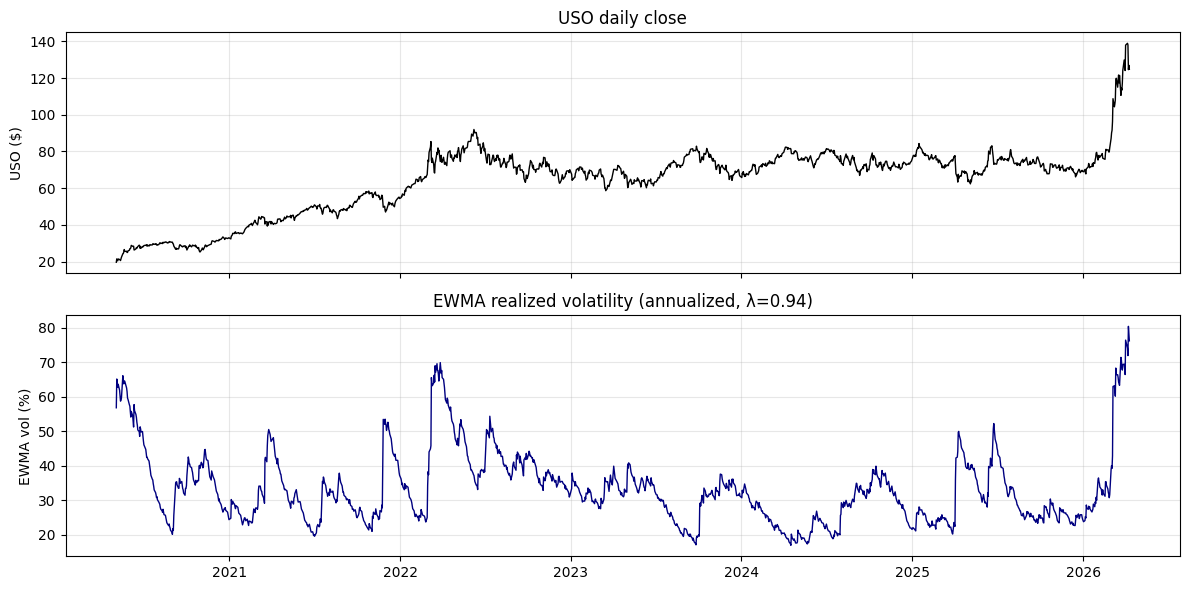

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(price['date'], price['uso_close'], color='black', lw=1)
axes[0].set_ylabel('USO ($)'); axes[0].set_title('USO daily close')
axes[1].plot(price['date'], price['ewma_vol_annual']*100, color='navy', lw=1)
axes[1].set_ylabel('EWMA vol (%)'); axes[1].set_title('EWMA realized volatility (annualized, λ=0.94)')
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()


## 3. Implied vs. realized volatility — the "vol risk premium"

For each trading day, look up the ATM 30-day straddle's mid implied vol and compare to
EWMA realized vol on the same day. Positive **IV − RV** is the volatility risk premium
the seller earns *on average*. The ratio version,

$$\text{signal}_t = \frac{IV_t}{RV_t^{\text{EWMA}}},$$

is what strategies **C** and **D** filter on (`signal > 1.10` to enter).


In [6]:
def daily_atm_iv(price, chain_by_date):
    out = []
    for _, r in price.iterrows():
        ch = chain_by_date.get(pd.Timestamp(r['date']))
        if ch is None: out.append(np.nan); continue
        pick = select_atm_straddle(ch, r['uso_close'])
        if pick is None: out.append(np.nan); continue
        c, p, _, _ = pick
        iv = (c['iv_mid'] + p['iv_mid']) / 2
        out.append(iv if iv > 0 else np.nan)
    return pd.Series(out, index=price.index)

price['atm_iv'] = daily_atm_iv(price, chain_by_date)


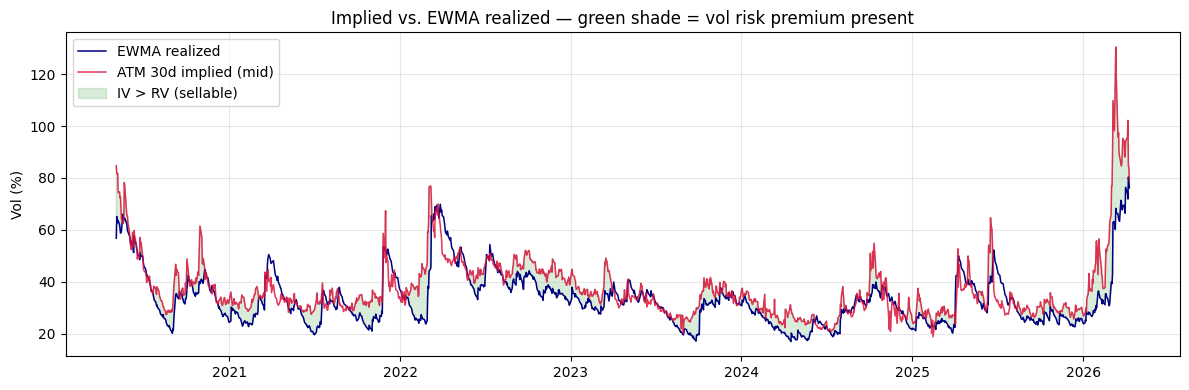

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(price['date'], price['ewma_vol_annual']*100, label='EWMA realized', color='navy', lw=1.1)
ax.plot(price['date'], price['atm_iv']*100, label='ATM 30d implied (mid)', color='crimson', lw=1.1, alpha=0.85)
ax.fill_between(price['date'], price['ewma_vol_annual']*100, price['atm_iv']*100,
                where=(price['atm_iv'] > price['ewma_vol_annual']),
                color='green', alpha=0.15, label='IV > RV (sellable)')
ax.set_title('Implied vs. EWMA realized — green shade = vol risk premium present')
ax.set_ylabel('Vol (%)'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()


**What you should see.** IV is *almost always* above EWMA realized. That gap is
the seller's edge in calm times — but a single spike (e.g. Mar-2022 invasion, Apr-2024
Iran-Israel) reverses many months of earnings. Strategies A/B sell every month
regardless; C/D sell only when the gap is at least 10%.

## 4. Run all four strategies

In [8]:
daily_by, trades_by, metrics_rows = {}, {}, []
for cfg in STRATEGIES:
    daily, trades = run_backtest(cfg, price, chain_by_date, price['ewma_vol_annual'])
    daily_by[cfg.name] = daily
    trades_by[cfg.name] = trades
    m = calculate_performance_metrics(daily['total_pnl'], trades)
    m['strategy'] = cfg.name
    metrics_rows.append(m)
metrics_df = pd.DataFrame(metrics_rows)[
    ['strategy','num_trades','total_pnl','ann_return_$','ann_vol_$','sharpe',
     'max_drawdown_$','win_rate_%','avg_trade_pnl','worst_trade','best_trade',
     'avg_holding_days','avg_tcost_per_trade']
]
metrics_df


,strategy,num_trades,total_pnl,ann_return_$,ann_vol_$,sharpe,max_drawdown_$,win_rate_%,avg_trade_pnl,worst_trade,best_trade,avg_holding_days,avg_tcost_per_trade
0,A_no_hedge_uncond,74,"-2,378.00",-401.65,"1,418.04",-0.28,"-5,068.50",67.57,-32.14,"-3,375.00","1,014.00",16.38,0.00
1,B_hedge_uncond,74,"-4,960.57",-837.84,"2,504.93",-0.33,"-8,643.46",64.86,-67.03,"-6,143.91","1,798.85",16.38,8.45
2,C_no_hedge_ewma,58,-104.00,-17.57,"1,352.71",-0.01,"-4,699.50",65.52,-1.79,"-2,865.00","1,308.00",16.57,0.00
3,D_hedge_ewma_stop,58,557.02,94.08,"1,826.47",0.05,"-4,858.64",58.62,9.60,"-1,667.88","2,018.90",15.10,7.81


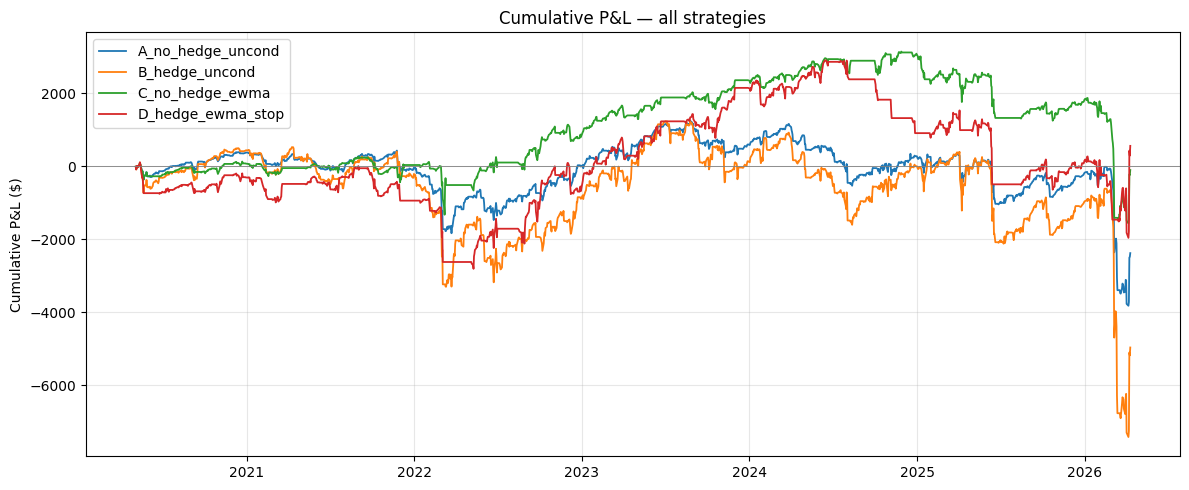

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, daily in daily_by.items():
    ax.plot(daily['date'], daily['total_pnl'].cumsum(), label=name, lw=1.3)
ax.axhline(0, color='grey', lw=0.6)
ax.set_title('Cumulative P&L — all strategies')
ax.set_ylabel('Cumulative P&L ($)'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()


## 5. Strategy A — Raw short straddle (no hedge, no filter)

**What it does**

- Every ~21 trading days, sell 1 ATM call + 1 ATM put (~30 DTE) — 1 contract = 100
  shares of underlying. Receive the bid premium.
- Hold to 5 trading days before expiry, close by buying back at ask.
- Mark-to-market at mid each day.
- **No hedge, no filter, no stop.**

**Mental model.** This is naked short volatility. You collect a premium up front and
hope the underlying barely moves until you can close the position cheaper than you
sold it. Two things hurt: (1) realized moves big enough to put either leg in the
money, (2) the IV repricing on the way there (vega loss).

**P&L formula (per trade)**

$$\text{Trade P\&L} = \big(C_{\text{bid}} + P_{\text{bid}}\big)\cdot 100
\;-\; \big(C_{\text{ask}}^{\text{exit}} + P_{\text{ask}}^{\text{exit}}\big)\cdot 100$$


In [10]:
A = trades_by['A_no_hedge_uncond']
print('Strategy A — first 5 trades')
A.head()


Strategy A — first 5 trades


,entry_date,exit_date,expiry,strike,premium_received,exit_reason,trade_pnl,option_pnl,hedge_pnl,transaction_costs,holding_days
0,2020-05-04,2020-05-29,2020-06-05,19.50,377.00,near_expiry,-275.00,-275.00,0.00,0.00,18
1,2020-06-02,2020-06-25,2020-07-02,27.00,344.00,near_expiry,138.00,138.00,0.00,0.00,17
2,2020-07-01,2020-07-24,2020-07-31,28.50,288.00,near_expiry,143.00,143.00,0.00,0.00,16
3,2020-07-30,2020-08-21,2020-08-28,29.00,239.00,near_expiry,92.00,92.00,0.00,0.00,16
4,2020-08-28,2020-09-18,2020-09-25,30.50,186.00,near_expiry,30.00,30.00,0.00,0.00,14


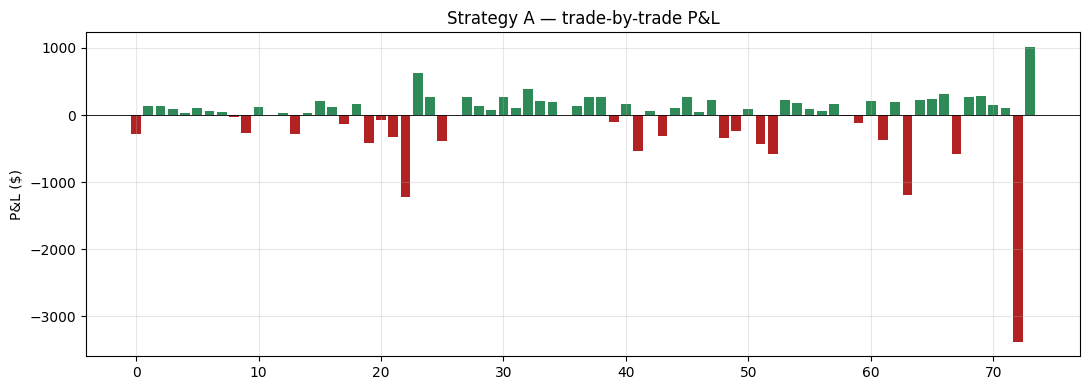

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(A)), A['trade_pnl'], color=['seagreen' if x>0 else 'firebrick' for x in A['trade_pnl']])
ax.axhline(0, color='black', lw=0.6)
ax.set_title('Strategy A — trade-by-trade P&L'); ax.set_ylabel('P&L ($)'); ax.grid(alpha=0.3)
plt.tight_layout()


**Read this chart.** Lots of small green bars (calm-month wins) and a handful
of large red bars (vol spikes). The classic *negatively skewed* short-vol payoff:
many small gains, a few catastrophic losses. The worst trade is your tail risk.

## 6. Strategy B — Add daily delta hedging

**What it does**

- Same straddle, same monthly cadence as A.
- After entering, every day rebalance underlying (USO shares) so the **net delta of
  (option position + hedge) is zero**.

**Why hedge?**  A short straddle's directional delta drifts as the underlying moves.
If oil rallies +10%, the short call's delta moves toward −1 and the short put toward
0; you're suddenly *short* the underlying. Hedging neutralizes that exposure so the
trade isolates *volatility* (IV vs realized) rather than *direction*.

**Hedge sizing**

$$\text{hedge shares}_t \;=\; -\big(\Delta^{\text{call}}_t + \Delta^{\text{put}}_t\big) \cdot 100$$

(positive = long USO, negative = short USO).

**Why it can hurt.** Delta hedging *converts unrealized gamma into realized P&L*. If
the underlying makes one big move and then mean-reverts, you buy high and sell low
along the way — that's the gamma cost. In trending oil regimes (2021, 2022 first
half) that cost was real, which is why **B underperforms A here**.

**Hedge cost.** 5 bps of notional traded each day (`HEDGE_COST_RATE = 0.0005`).


In [12]:
B = trades_by['B_hedge_uncond']
print('Strategy B — option vs hedge attribution')
B[['entry_date','exit_date','option_pnl','hedge_pnl','transaction_costs','trade_pnl']].head(10)


Strategy B — option vs hedge attribution


,entry_date,exit_date,option_pnl,hedge_pnl,transaction_costs,trade_pnl
0,2020-05-04,2020-05-29,-275.00,-296.02,3.09,-574.11
1,2020-06-02,2020-06-25,138.00,124.37,3.37,259.00
2,2020-07-01,2020-07-24,143.00,16.87,2.94,156.93
3,2020-07-30,2020-08-21,92.00,6.18,2.79,95.39
4,2020-08-28,2020-09-18,30.00,92.83,3.21,119.62
5,2020-09-28,2020-10-23,103.00,122.03,4.59,220.44
6,2020-10-27,2020-11-20,68.00,54.12,4.60,117.51
7,2020-11-25,2020-12-17,53.00,-33.33,2.94,16.73
8,2020-12-24,2021-01-15,-30.00,-24.89,3.91,-58.80
9,2021-01-22,2021-02-12,-260.00,-256.50,4.02,-520.52


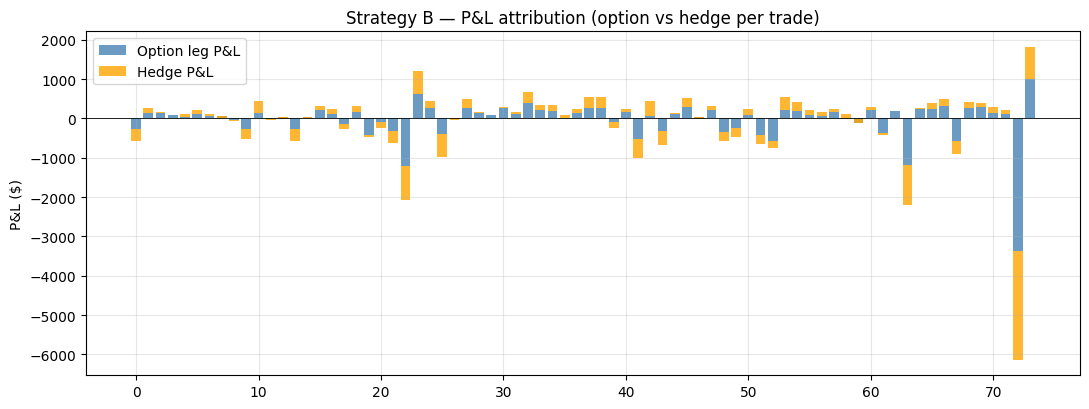

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(range(len(B)), B['option_pnl'], label='Option leg P&L', color='steelblue', alpha=0.8)
ax.bar(range(len(B)), B['hedge_pnl'], bottom=B['option_pnl'], label='Hedge P&L', color='orange', alpha=0.8)
ax.axhline(0, color='black', lw=0.6)
ax.set_title('Strategy B — P&L attribution (option vs hedge per trade)')
ax.set_ylabel('P&L ($)'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()


**Read this chart.** The *option leg* P&L is similar to A. The *hedge leg* is
the new piece — sometimes positive (hedge made money chasing the move), sometimes a
big offsetting loss. The point: B is *less directional* than A but not necessarily
more profitable. Hedging is a risk-management tool, not an alpha source.

## 7. Strategy C — Add the EWMA timing filter

**What it does**

- Same straddle as A (still no hedge), but only enter when

$$\frac{IV_t}{\sigma^{\text{EWMA}}_t} > 1.10.$$

**Intuition.** When realized vol is *near* implied vol, the seller's edge is gone.
The filter sits out months where IV is barely above (or below) the realized
forecast — exactly the regimes where short-vol blows up because IV was already
priced for the coming move.

In [14]:
C = trades_by['C_no_hedge_ewma']
print(f'Trades A: {len(trades_by["A_no_hedge_uncond"])} → C: {len(C)} '
      f'({len(trades_by["A_no_hedge_uncond"])-len(C)} skipped by filter)')


Trades A: 74 → C: 58 (16 skipped by filter)


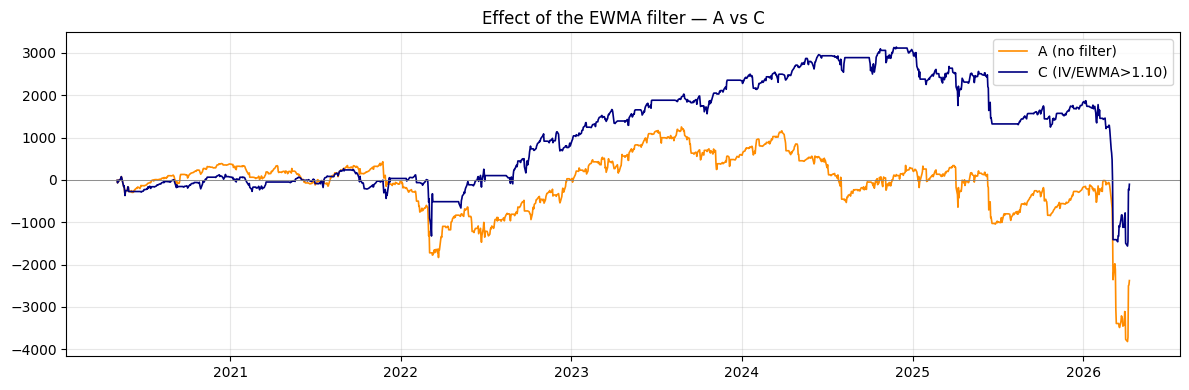

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_by['A_no_hedge_uncond']['date'],
        daily_by['A_no_hedge_uncond']['total_pnl'].cumsum(),
        label='A (no filter)', color='darkorange', lw=1.2)
ax.plot(daily_by['C_no_hedge_ewma']['date'],
        daily_by['C_no_hedge_ewma']['total_pnl'].cumsum(),
        label='C (IV/EWMA>1.10)', color='navy', lw=1.2)
ax.set_title('Effect of the EWMA filter — A vs C')
ax.axhline(0, color='grey', lw=0.6); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()


**Read this chart.** C should sit *above* A almost everywhere — the filter
removes a chunk of the worst trades without giving up many of the good ones.

## 8. Strategy D — Hedge + filter + stop loss (the Layer 1 baseline)

**What it does**

- EWMA filter (like C) + daily delta hedge (like B) + **stop loss**:

$$\text{exit if } \big(C^{\text{ask}}_t + P^{\text{ask}}_t\big)\cdot 100 \;\geq\; 2 \times \text{premium received}.$$

i.e. cut the trade if the straddle has doubled in price against you.

**Why all three.** The filter improves the win rate, the hedge reduces directional
sensitivity, the stop caps the tail. Together they convert a negative-Sharpe naked
short-vol into a (small) positive-Sharpe baseline — the deliverable for Layer 1.

In [16]:
D = trades_by['D_hedge_ewma_stop']
print('Stop-loss exits in D:', (D['exit_reason']=='stop_loss').sum(), '/', len(D))
D[['entry_date','exit_date','exit_reason','option_pnl','hedge_pnl','transaction_costs','trade_pnl']].head(10)


Stop-loss exits in D: 12 / 58


,entry_date,exit_date,exit_reason,option_pnl,hedge_pnl,transaction_costs,trade_pnl
0,2020-05-04,2020-05-21,stop_loss,-377.00,-357.29,2.86,-737.15
1,2020-06-24,2020-07-17,near_expiry,113.00,-20.68,3.20,89.12
2,2020-07-23,2020-08-14,near_expiry,123.00,18.63,3.20,138.43
3,2020-08-21,2020-09-11,near_expiry,-118.00,-55.53,3.92,-177.45
4,2020-09-23,2020-10-16,near_expiry,95.00,100.48,4.66,190.81
5,2020-10-22,2020-11-13,near_expiry,125.00,128.22,3.74,249.48
6,2020-12-01,2020-12-24,near_expiry,14.00,-63.62,3.71,-53.32
7,2020-12-30,2021-01-22,near_expiry,-15.00,-1.39,4.08,-20.47
8,2021-01-28,2021-02-16,stop_loss,-292.00,-284.33,3.55,-579.88
9,2021-02-26,2021-03-19,near_expiry,120.00,302.32,6.45,415.87


### Drawdowns side-by-side

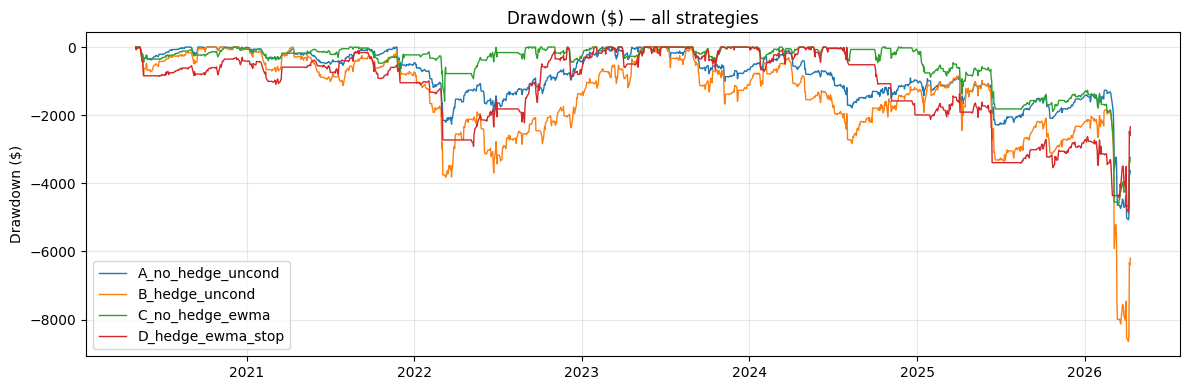

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
for name, daily in daily_by.items():
    cum = daily['total_pnl'].cumsum()
    dd  = cum - cum.cummax()
    ax.plot(daily['date'], dd, label=name, lw=1.0)
ax.set_title('Drawdown ($) — all strategies')
ax.set_ylabel('Drawdown ($)'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()


### Trade-P&L distributions side-by-side

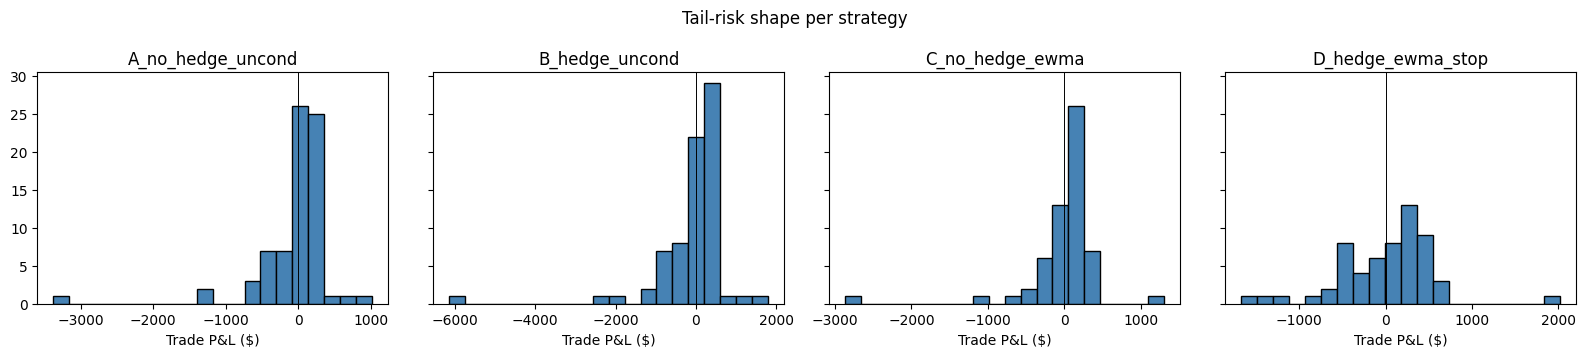

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for ax, (name, tl) in zip(axes, trades_by.items()):
    ax.hist(tl['trade_pnl'], bins=20, color='steelblue', edgecolor='black')
    ax.axvline(0, color='black', lw=0.7)
    ax.set_title(name); ax.set_xlabel('Trade P&L ($)')
fig.suptitle('Tail-risk shape per strategy')
plt.tight_layout()


**Read these charts.** Watch the **left tail**: A and B have a long red tail
(no protection); C truncates the bad months by sitting them out; D additionally caps
losses with the stop. The body of the distribution shifts very little — most of the
improvement is in the worst 5% of trades.

## 9. What each component buys you (summary)

| Component | What it does | What it costs |
|---|---|---|
| **Selling the straddle** | Collects the vol risk premium (IV − RV) | Negatively skewed P&L |
| **Daily delta hedge** | Removes directional exposure so the trade is *pure vol* | Realized gamma loss in trending regimes; t-cost (5 bps) |
| **EWMA filter** | Skips months where IV ≈ RV (no edge) | Fewer trades → lower deployed capital, occasional missed wins |
| **Stop loss** | Caps tail risk | Locks in losses on trades that would have recovered |

**Layer-1 takeaway.** None of these on its own makes the strategy profitable. The
combination — sell when there's premium, hedge the direction away, cut the bad ones
fast — is what produces a positive (small) Sharpe over six years that contains the
2020 oil crash, the 2022 invasion, and the 2024 Mideast spikes.

## 10. Where to go next (Layer 2)

- Add **COT positioning** to refine the entry signal (e.g. only sell vol when CTAs
  are not extreme short).
- Add **option skew & term structure** features (sell richer wings, avoid inverted
  term structures).
- Replace EWMA with **GARCH(1,1)** or **HAR-RV** and compare forecast quality vs.
  realized.
- Switch to a richer execution model (slippage proportional to size, spread
  scaling with vol).
